<a href="https://www.kaggle.com/code/mrafraim/dl-day-41-cnn-evaluation-debugging?scriptVersionId=303030113" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Day 41: CNN Evaluation & Debugging

*Confusion Matrix • ROC Curves •  Precision–Recall Curves • Error Analysis*

Welcome to Day 41!

Today You’ll Learn

1. Why accuracy alone is misleading
2. How to interpret confusion matrices
3. ROC curves and AUC interpretation
4. Precision–Recall curves for imbalanced data
5. Systematic error analysis
6. A professional CNN debugging workflow

If you found this notebook helpful, your **<b style="color:skyblue;">UPVOTE</b>** would be greatly appreciated! It helps others discover the work and supports continuous improvement.

---

# Why Accuracy Is Not Enough

## Problem With Accuracy

Accuracy measures:

Correct Predictions / Total Predictions

However, it hides important information when the dataset is imbalanced.

Example dataset:

- Class A = 90%  
- Class B = 10%

If the model predicts Class A for every image:

Accuracy = 90%

Yet the model never detects Class B.

## Why This Happens

Accuracy does not distinguish between:

• Majority class performance  
• Minority class failure  

This is why deeper evaluation metrics are required.

## Better Diagnostic Tools

Professional evaluation includes:

• Confusion Matrix  
• Per-class precision and recall  
• ROC curve and AUC  
• Precision–Recall curve  
• Error analysis of misclassified samples

# Confusion Matrix

A confusion matrix compares true labels vs predicted labels.

For a 3-class problem:

| Actual \ Pred | Cat | Dog | Bird |
|---------------|-----|-----|------|
| Cat           | 40  | 5   | 2    |
| Dog           | 6   | 50  | 3    |
| Bird          | 1   | 4   | 35   |

**Interpretation**

Diagonal elements:

- Correct predictions.

Off-diagonal elements:

- Misclassifications.

**What We Learn From This Matrix**

Example insights:

• Dogs often predicted as cats  
• Birds rarely confused with cats  
• Cat–dog boundary is weak

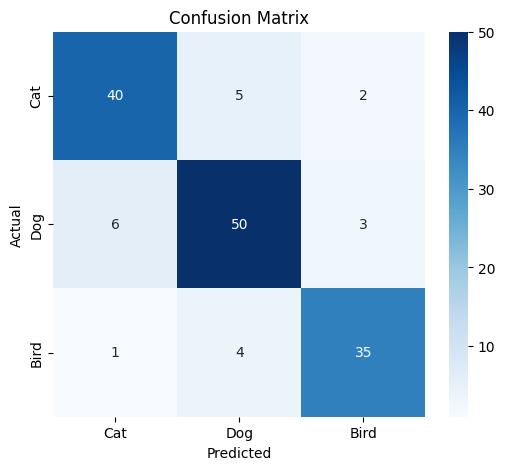

In [1]:
# Confusion Matrix Visualization

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# -----------------------------
# Step 1: Create the confusion matrix
# -----------------------------

cm = np.array([
    [40, 5, 2],  # Actual Cat
    [6, 50, 3],  # Actual Dog
    [1, 4, 35]   # Actual Bird
])

# -----------------------------
# Step 2: Visualize
# -----------------------------
class_names = ['Cat', 'Dog', 'Bird']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve

The Receiver Operating Characteristic (ROC) curve is a standard evaluation tool for binary classification or one-vs-rest multi-class classification. It visually illustrates the tradeoff between True Positive Rate (Recall) and False Positive Rate as the decision threshold changes.

## True Positive Rate (TPR)

Also called **Recall** or **Sensitivity**:

$$
TPR = \frac{TP}{TP + FN}
$$

- Measures how many actual positives are correctly detected.  
- High TPR → fewer missed positives.

## False Positive Rate (FPR)

$$
FPR = \frac{FP}{FP + TN}
$$

- Measures how many actual negatives are incorrectly predicted as positive.  
- Low FPR → fewer false alarms.


## ROC Curve

- X-axis: **FPR**  
- Y-axis: **TPR**

As you vary the classification threshold, the curve shows the tradeoff between detecting positives and generating false positives.


## AUC: Area Under the Curve

- **AUC** quantifies the overall ability of the model to separate classes.  
- Interpretation:

| AUC | Meaning |
|-----|---------|
| 1.0 | Perfect classifier |
| 0.9–0.99 | Excellent |
| 0.8–0.9 | Good |
| 0.7–0.8 | Fair |
| 0.5 | Random guessing |

> Higher AUC means the model ranks positive instances higher than negative ones more consistently.

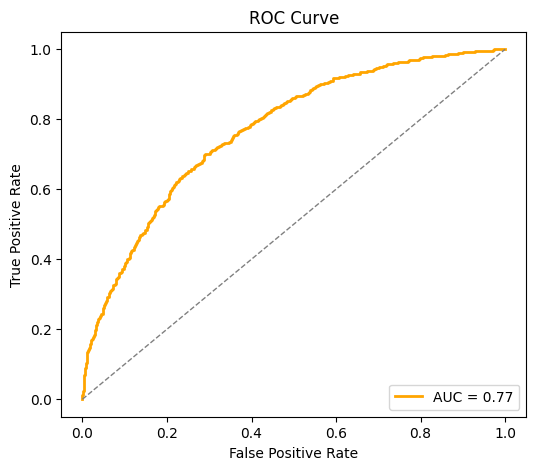

In [2]:
# ROC Curve Visualization with Dummy Data

import torch
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Create dummy logits for binary classification
# -----------------------------
# 0 = Negative, 1 = Positive
np.random.seed(42)

num_samples = 2000
true_labels = np.random.choice([0, 1], size=num_samples, p=[0.6, 0.4])
labels = torch.tensor(true_labels)

# Simulate model logits (before activation)
# Positive samples get slightly higher logits on average
logits = np.random.normal(loc=0.0, scale=1.0, size=num_samples) + true_labels * 1.0
outputs = torch.tensor(np.stack([ -logits, logits ], axis=1))  # two logits per sample

# -----------------------------
# Step 2: Convert logits to probabilities for positive class
# -----------------------------
probs = torch.softmax(outputs, dim=1)[:,1].cpu().detach().numpy()

# -----------------------------
# Step 3: Compute ROC curve and AUC
# -----------------------------
fpr, tpr, thresholds = roc_curve(true_labels, probs)
roc_auc = auc(fpr, tpr)

# -----------------------------
# Step 4: Plot ROC curve
# -----------------------------

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

## Important Note

ROC curves are mainly used for:

• Binary classification  
• One-vs-rest multi-class setups

# Precision–Recall Curve

The **Precision–Recall (PR) curve** is a key evaluation tool for binary classification, especially when the dataset is highly imbalanced.

Instead of comparing **TPR vs FPR** like ROC curves, PR curves focus only on positive class performance, which is often the main concern in real-world problems.

## Why PR Curves Are Important

ROC curves can sometimes look overly optimistic when the negative class dominates the dataset.

Example:

| Class | Samples |
|------|------|
| Negative | 9900 |
| Positive | 100 |

A model that predicts mostly negatives may still produce a reasonable ROC curve, but it may perform poorly at actually detecting positives.

Precision–Recall curves solve this by focusing on:

- How accurate positive predictions are
- How many real positives are detected

This makes PR curves particularly useful for:

- **Fraud detection**
- **Medical diagnosis**
- **Anomaly detection**
- **Rare-event detection**

The PR curve plots:

| Axis | Metric |
|-----|------|
| X-axis | Recall |
| Y-axis | Precision |

As the decision threshold changes, the model produces different precision–recall pairs.

Typical behavior:

| Threshold | Precision | Recall |
|------|------|------|
| Low threshold | Lower | High |
| Medium threshold | Balanced | Balanced |
| High threshold | High | Lower |

This curve helps determine the best operating threshold for the model.

## Area Under PR Curve (Average Precision)

Similar to ROC-AUC, the PR curve can be summarized using Average Precision (AP).

Interpretation:

| AP Score | Meaning |
|------|------|
| 1.0 | Perfect model |
| 0.8–0.9 | Very strong |
| 0.6–0.8 | Moderate |
| < 0.5 | Weak classifier |

Higher AP means the model maintains high precision even at high recall levels.

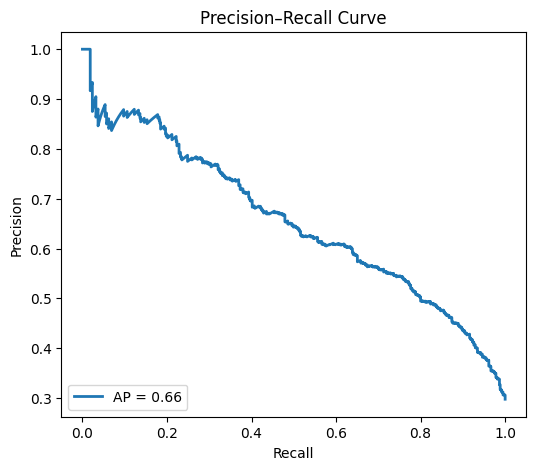

In [3]:
import torch
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Dummy example logits
np.random.seed(42)
num_samples = 2000

true_labels = np.random.choice([0,1], size=num_samples, p=[0.7,0.3])
labels = torch.tensor(true_labels)

logits = np.random.normal(0,1,num_samples) + true_labels*1.2
outputs = torch.tensor(np.stack([-logits, logits], axis=1))

# Convert logits to probabilities
probs = torch.softmax(outputs, dim=1)[:,1].numpy()

# Compute PR curve
precision, recall, thresholds = precision_recall_curve(true_labels, probs)

# Compute Average Precision
ap = average_precision_score(true_labels, probs)

# Plot PR curve
plt.figure(figsize=(6,5))
plt.plot(recall, precision, lw=2, label=f'AP = {ap:.2f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(loc="lower left")
plt.show()

# Error Analysis

Training metrics (accuracy, F1, AUC, etc.) tell you how well the model performs, but they do not explain why the model fails.

In real ML workflows, error analysis is the stage where practitioners investigate failure modes to improve the model, dataset, or training pipeline.

> Metrics tell what went wrong.  
> Error analysis tells why it went wrong.

This step is critical before trying random fixes like new architectures or hyperparameters.

## What Real ML Practitioners Do

Experienced ML engineers follow a structured debugging process:

1. **Quantify errors using metrics**
2. **Locate the incorrect predictions**
3. **Visually inspect mistakes**
4. **Identify systematic patterns**
5. **Fix the root cause**

Many major ML improvements actually come from better data and debugging, not just better models.

## Key Debugging Questions

When analyzing model errors, practitioners typically investigate:

### 1. Which classes are most confused?

Look at the **confusion matrix**.

Example:

| Actual \ Pred | Cat | Dog | Bird |
|---------------|-----|-----|------|
| Cat           | 40  | 5   | 2    |
| Dog           | 6   | 50  | 3    |
| Bird          | 1   | 4   | 35   |

This reveals patterns such as:

- Cat ↔ Dog confusion
- Bird occasionally predicted as Dog

These patterns suggest feature similarity or dataset issues.


### 2. Are errors caused by visual conditions?

Common causes in computer vision:

• **Lighting conditions**  
• **Occlusion (object partially hidden)**  
• **Low resolution images**  
• **Unusual camera viewpoints**  
• **Background clutter**

Example:

- A dog partly hidden behind a table may be predicted as a cat.

These errors often suggest data augmentation or dataset expansion is needed.


### 3. Are labels noisy or incorrect?

In real datasets, label noise is common.

Example problems:

- Wrong annotation
- Missing labels
- Ambiguous categories

Fixing mislabeled samples can sometimes improve performance more than model tuning.

## Identifying Incorrect Predictions

First identify where the model made mistakes.

```python
wrong = preds != true

wrong_images = images[wrong]
wrong_preds = preds[wrong]
wrong_labels = true[wrong]
```

This extracts:

* images the model predicted incorrectly
* predicted labels
* true labels

These samples become the primary focus of analysis.

## Manual Inspection

After extracting incorrect samples, manually inspect them.

Focus on:

• **hardest mistakes** (high confidence but wrong)

• **systematic patterns** (same mistake repeated)

• **mislabeled samples**

Example workflow:

1. Sort mistakes by prediction confidence
2. Inspect top 50 wrong predictions
3. Categorize errors

Example categories:

| Error Type        | Example Cause            |
| ----------------- | ------------------------ |
| Visual similarity | Cat vs Dog               |
| Occlusion         | Partially hidden objects |
| Poor lighting     | Dark images              |
| Dataset bias      | Rare viewpoints          |
| Label noise       | Incorrect annotation     |


## Typical Error Analysis Workflow

A common debugging pipeline used in ML teams:

```
Train model
     ↓
Evaluate metrics
     ↓
Generate confusion matrix
     ↓
Extract wrong predictions
     ↓
Manually inspect samples
     ↓
Identify systematic patterns
     ↓
Improve dataset / training
```

## Practical Reality

In production ML systems, data quality often matters more than model complexity.

Typical fixes discovered during error analysis include:

- adding more training data
- fixing label errors
- improving class balance
- adding targeted data augmentation
- refining class definitions


# Professional CNN Debugging Workflow

In real-world machine learning projects, debugging a CNN is not random trial-and-error.  
Experienced practitioners follow a structured diagnostic workflow to identify whether the problem lies in:

- the **model**
- the **data**
- the **training process**
- the **evaluation strategy**

The goal is to locate the root cause before applying fixes.

## Step 1: Check Training vs Validation Loss

The first diagnostic step is analyzing the **learning curves**.

Plot:

- **Training loss**
- **Validation loss**

over epochs.

Interpretation:

| Pattern | Meaning |
|------|------|
| Training ↓ but Validation ↑ | **Overfitting** |
| Both losses high | **Underfitting** |
| Both decreasing smoothly | Healthy training |
| Validation fluctuates strongly | Data instability or small validation set |

### Typical Causes

**Overfitting**

- small dataset
- weak regularization
- model too complex

**Underfitting**

- insufficient model capacity
- poor feature extraction
- inadequate training

### Typical Fixes

Overfitting:

- stronger augmentation  
- dropout / regularization  
- early stopping  
- smaller model

Underfitting:

- deeper architecture  
- longer training  
- better features


## Step 2: Inspect Confusion Matrix

Once training behavior looks reasonable, analyze class-level errors.

A confusion matrix reveals systematic mistakes.

Example:

| Actual \ Pred | Cat | Dog | Bird |
|---------------|-----|-----|------|
| Cat           | 40  | 5   | 2    |
| Dog           | 6   | 50  | 3    |
| Bird          | 1   | 4   | 35   |

Insights:

- **Cat ↔ Dog confusion** → visually similar classes  
- **Bird → Dog errors** → possible dataset imbalance or feature issues

This step helps determine whether the model is struggling with specific class relationships.

## Step 3: Analyze PR or ROC Curves

Metrics like accuracy or F1 summarize performance, but curves reveal threshold behavior.

Two important curves:

### ROC Curve

Shows tradeoff between:

- **True Positive Rate (Recall)**
- **False Positive Rate**

Useful when classes are balanced.


### Precision–Recall Curve

Shows tradeoff between:

- **Precision**
- **Recall**

More informative when:

- dataset is imbalanced
- positive class is rare

These curves help determine the best decision threshold for deployment.

## Step 4: Visualize Misclassified Images

This is one of the **most valuable debugging steps**.

Extract incorrect predictions:

```python
wrong = preds != true

wrong_images = images[wrong]
wrong_preds = preds[wrong]
wrong_labels = true[wrong]
```

# Common Evaluation Mistakes

• Reporting only accuracy  
• Ignoring class imbalance  
• Evaluating model in training mode  
• Using fixed thresholds without tuning  
• Never inspecting model errors

# Key Takeaways from Day 41

• Accuracy alone is misleading  
• Confusion matrix reveals class-level errors  
• ROC curve measures class separability  
• PR curve is better for imbalanced datasets  
• Error analysis is the most powerful debugging tool

---
<p style="text-align:center; color:skyblue; font-size:18px;">
© 2026 Mostafizur Rahman
</p>
